## Type classification

In [2]:
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04



# Load the CSV file
df = pd.read_csv('10-Los-compression_size_results/all_results.csv')  # Replace with your actual file path

# Filter rows where 'File Name' contains 'Topology_B'
topology_b_df = df[df['File Name'].str.contains(TOPOLOGY, na=False)]

# Extract b values and corresponding LZMA Size (KB)
results = {}
for _, row in topology_b_df.iterrows():
    filename = row['File Name']
    lzma_size = row['LZMA Size (KB)']
    
    # Extract b value (e.g., b1, b2, b3, etc.)
    match = re.search(r'b(\d+)', filename)
    if match:
        b_key = f"b{match.group(1)}"
        if b_key not in results:
            results[b_key] = []
        results[b_key].append(lzma_size)

# Display results
for b_key in sorted(results.keys(), key=lambda x: int(x[1:])):
    results[b_key] = [results[b_key][0] * MUL_FACTOR]
    print(f"{b_key}: {results[b_key]}")
    
    


b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 32 64]
  Range: 0.2390 - 0.9722

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 32 64]
  Range: 0.6855 - 0.9721


/tmp/ipykernel_17856/835801521.py:229: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


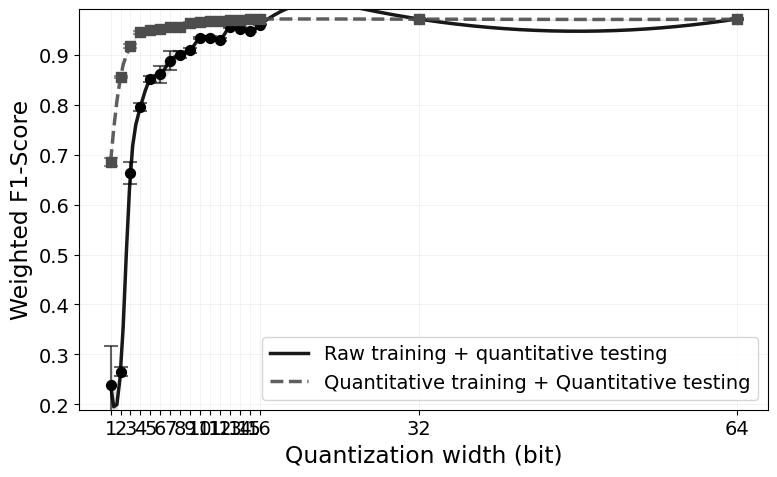


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.2390 ± 0.0779
b=2: 0.2655 ± 0.0084
b=3: 0.6632 ± 0.0226
b=4: 0.7957 ± 0.0075
b=5: 0.8521 ± 0.0056
b=6: 0.8611 ± 0.0171
b=7: 0.8885 ± 0.0194
b=8: 0.9009 ± 0.0071
b=9: 0.9094 ± 0.0052
b=10: 0.9342 ± 0.0025
b=11: 0.9344 ± 0.0042
b=12: 0.9308 ± 0.0037
b=13: 0.9556 ± 0.0019
b=14: 0.9523 ± 0.0031
b=15: 0.9473 ± 0.0019
b=16: 0.9604 ± 0.0012
b=32: 0.9722 ± 0.0014
b=64: 0.9722 ± 0.0015

Quantitative training + Quantitative testing：
b=1: 0.6855 ± 0.0079
b=2: 0.8555 ± 0.0016
b=3: 0.9177 ± 0.0043
b=4: 0.9455 ± 0.0025
b=5: 0.9496 ± 0.0028
b=6: 0.9528 ± 0.0023
b=7: 0.9571 ± 0.0013
b=8: 0.9569 ± 0.0023
b=9: 0.9641 ± 0.0021
b=10: 0.9656 ± 0.0024
b=11: 0.9678 ± 0.0016
b=12: 0.9687 ± 0.0017
b=13: 0.9707 ± 0.0014
b=14: 0.9711 ± 0.0020
b=15: 0.9719 ± 0.0021
b=16: 0.9721 ± 0.0018
b=32: 0.9716 ± 0.0014
b=64: 0.9716 ± 0.0014
"""




"""
Raw training + quantitative testing:
b=1: 0.2941 ± 0.0267
b=2: 0.4483 ± 0.0356
b=3: 0.6276 ± 0.0191
b=4: 0.7715 ± 0.0152
b=5: 0.8548 ± 0.0060
b=6: 0.8869 ± 0.0078
b=7: 0.8949 ± 0.0067
b=8: 0.9090 ± 0.0025
b=9: 0.9185 ± 0.0048
b=10: 0.9414 ± 0.0014
b=11: 0.9332 ± 0.0047
b=12: 0.9528 ± 0.0032
b=13: 0.9556 ± 0.0026
b=14: 0.9523 ± 0.0039
b=15: 0.9274 ± 0.0080
b=16: 0.9591 ± 0.0023

Quantitative training + Quantitative testing：
b=1: 0.6801 ± 0.0057
b=2: 0.8788 ± 0.0036
b=3: 0.9223 ± 0.0027
b=4: 0.9408 ± 0.0033
b=5: 0.9463 ± 0.0033
b=6: 0.9495 ± 0.0038
b=7: 0.9528 ± 0.0032
b=8: 0.9557 ± 0.0030
b=9: 0.9639 ± 0.0025
b=10: 0.9675 ± 0.0019
b=11: 0.9692 ± 0.0018
b=12: 0.9693 ± 0.0016
b=13: 0.9692 ± 0.0019
b=14: 0.9694 ± 0.0022
b=15: 0.9695 ± 0.0026
b=16: 0.9706 ± 0.0028
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

/tmp/ipykernel_14799/2737293018.py:193: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


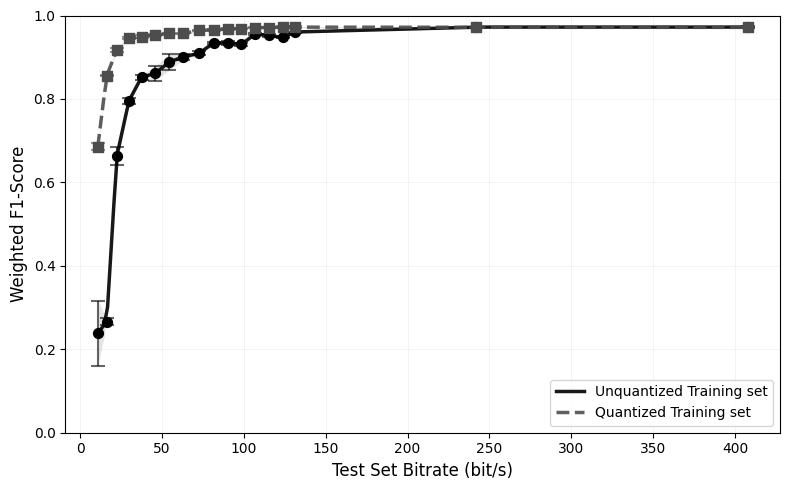


Figure generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re


# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.2390 ± 0.0779
b=2: 0.2655 ± 0.0084
b=3: 0.6632 ± 0.0226
b=4: 0.7957 ± 0.0075
b=5: 0.8521 ± 0.0056
b=6: 0.8611 ± 0.0171
b=7: 0.8885 ± 0.0194
b=8: 0.9009 ± 0.0071
b=9: 0.9094 ± 0.0052
b=10: 0.9342 ± 0.0025
b=11: 0.9344 ± 0.0042
b=12: 0.9308 ± 0.0037
b=13: 0.9556 ± 0.0019
b=14: 0.9523 ± 0.0031
b=15: 0.9473 ± 0.0019
b=16: 0.9604 ± 0.0012
b=32: 0.9722 ± 0.0014
b=64: 0.9722 ± 0.0015

Quantitative training + Quantitative testing：
b=1: 0.6855 ± 0.0079
b=2: 0.8555 ± 0.0016
b=3: 0.9177 ± 0.0043
b=4: 0.9455 ± 0.0025
b=5: 0.9496 ± 0.0028
b=6: 0.9528 ± 0.0023
b=7: 0.9571 ± 0.0013
b=8: 0.9569 ± 0.0023
b=9: 0.9641 ± 0.0021
b=10: 0.9656 ± 0.0024
b=11: 0.9678 ± 0.0016
b=12: 0.9687 ± 0.0017
b=13: 0.9707 ± 0.0014
b=14: 0.9711 ± 0.0020
b=15: 0.9719 ± 0.0021
b=16: 0.9721 ± 0.0018
b=32: 0.9716 ± 0.0014
b=64: 0.9716 ± 0.0014
"""


# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Get the two conditions
cond_names = list(conditions.keys())
cond1_name = cond_names[0]
cond2_name = cond_names[1]
cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Map b values to LZMA sizes
lzma_for_b = []
for b in cond1['b']:
    b_key = f"b{b}"
    if b_key in results:
        lzma_for_b.append(results[b_key][0])
    else:
        lzma_for_b.append(np.nan)

lzma_for_b = np.array(lzma_for_b)

# Sort by LZMA size for proper interpolation
sort_idx = np.argsort(lzma_for_b)
lzma_sorted = lzma_for_b[sort_idx]
cond1_mean_sorted = cond1['mean'][sort_idx]
cond1_std_sorted = cond1['std'][sort_idx]
cond2_mean_sorted = cond2['mean'][sort_idx]
cond2_std_sorted = cond2['std'][sort_idx]

# Create interpolation functions for means
interp_cond1 = interp1d(lzma_sorted, cond1_mean_sorted, kind='linear')
interp_cond2 = interp1d(lzma_sorted, cond2_mean_sorted, kind='linear')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(lzma_sorted, cond1_std_sorted, kind='linear')
interp_cond2_std = interp1d(lzma_sorted, cond2_std_sorted, kind='linear')

# Extended arrays for smooth visualization
lzma_smooth = np.linspace(lzma_sorted.min(), lzma_sorted.max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(lzma_smooth)
cond2_smooth = interp_cond2(lzma_smooth)
cond1_std_smooth = interp_cond1_std(lzma_smooth)
cond2_std_smooth = interp_cond2_std(lzma_smooth)

# Professional black and white styling
color_cond1 = '#000000'
color_cond2 = '#4D4D4D'
linestyle_cond1 = '-'
linestyle_cond2 = '--'
marker_cond1 = 'o'
marker_cond2 = 's'

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

cond1_name_lable = "Unquantized Training set"  #cond_names[0]
cond2_name_lable = "Quantized Training set"

# Plot Condition 1 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(lzma_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name_lable, alpha=0.9)
ax.errorbar(lzma_sorted, cond1_mean_sorted, yerr=cond1_std_sorted,
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond1_mean_sorted, 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(lzma_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name_lable, alpha=0.9)
ax.errorbar(lzma_sorted, cond2_mean_sorted, yerr=cond2_std_sorted,
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond2_mean_sorted, 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure

ax.set_xlabel('Test Set Bitrate (bit/s)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium', frameon=True, fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, )

plt.tight_layout()
plt.savefig('dev_type-f1-weight_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

# bitrate based plots

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re
import pandas as pd

def plot_f1(x_lim=0, select='all'):
    global TOPOLOGY, MUL_FACTOR, REFERENCE_X, REFERENCE_Y, REFERENCE_STD, F1_TYPE, data_text
    # ============================================================
    # LZMA RESULTS - Load from CSV
    # ============================================================

    # Load the CSV file
    df = pd.read_csv('10-Los-compression_size_results/all_results.csv')

    # Filter rows where 'File Name' contains the topology
    topology_b_df = df[df['File Name'].str.contains(TOPOLOGY, na=False)]

    # Extract b values and corresponding LZMA Size (KB)
    results = {}
    for _, row in topology_b_df.iterrows():
        filename = row['File Name']
        lzma_size = row['LZMA Size (KB)']
        
        match = re.search(r'b(\d+)', filename)
        if match:
            b_key = f"b{match.group(1)}"
            if b_key not in results:
                results[b_key] = []
            results[b_key].append(lzma_size)

    # Display results
    for b_key in sorted(results.keys(), key=lambda x: int(x[1:])):
        results[b_key] = [results[b_key][0] * MUL_FACTOR]
        print(f"{b_key}: {results[b_key]}")

    # ============================================================

    def parse_data(text):
        """Parse the data format and extract b values, means, and stds for each condition"""
        conditions = {}
        
        text = text.replace('：', ':')
        condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
        matches = re.finditer(condition_pattern, text)
        
        for match in matches:
            condition_name = match.group(1).strip()
            data_part = match.group(2).strip()
            
            value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
            value_matches = re.findall(value_pattern, data_part)
            
            b_values = []
            means = []
            stds = []
            
            for value_match in value_matches:
                b_values.append(int(value_match[0]))
                means.append(float(value_match[1]))
                stds.append(float(value_match[2]))
            
            if b_values:
                conditions[condition_name] = {
                    'b': np.array(b_values),
                    'mean': np.array(means),
                    'std': np.array(stds)
                }
        
        return conditions

    # Parse the data
    conditions = parse_data(data_text)

    # Get the two conditions
    cond_names = list(conditions.keys())
    cond1_name = cond_names[0]
    cond2_name = cond_names[1]
    cond1 = conditions[cond1_name]
    cond2 = conditions[cond2_name]


    def filter_indices(n, select):
        """
        Generate indices based on selection criteria (1-based counting).
        - 'all': keep all elements
        - 'even': keep elements at positions 2, 4, 6, ... (0-indexed: 1, 3, 5, ...)
                  + always include first (position 1, index 0)
                  + include last if total count is odd (last position is odd)
        - 'odd': keep elements at positions 1, 3, 5, ... (0-indexed: 0, 2, 4, ...)
                 + include last if total count is even (last position is even)
        """
        if select == 'all':
            return list(range(n))
        elif select == 'even':
            # Keep even positions (2, 4, 6, ...) which are 0-indexed as (1, 3, 5, ...)
            indices = [i for i in range(n) if (i + 1) % 2 == 0]
            # Always include first element (position 1, index 0)
            if 0 not in indices:
                indices.insert(0, 0)
            # Include last element if total count is odd (last position is odd)
            if n % 2 == 1 and (n - 1) not in indices:
                indices.append(n - 1)
            return sorted(indices)
        elif select == 'odd':
            # Keep odd positions (1, 3, 5, ...) which are 0-indexed as (0, 2, 4, ...)
            indices = [i for i in range(n) if (i + 1) % 2 == 1]
            # Include last element if total count is even (last position is even)
            if n % 2 == 0 and (n - 1) not in indices:
                indices.append(n - 1)
            return sorted(indices)
        else:
            raise ValueError(f"select must be 'all', 'even', or 'odd', got '{select}'")


    # Get the number of elements
    n_elements = len(cond1['b'])
    selected_indices = filter_indices(n_elements, select)

    # Apply filter to both conditions
    cond1 = {
        'b': cond1['b'][selected_indices],
        'mean': cond1['mean'][selected_indices],
        'std': cond1['std'][selected_indices]
    }
    cond2 = {
        'b': cond2['b'][selected_indices],
        'mean': cond2['mean'][selected_indices],
        'std': cond2['std'][selected_indices]
    }

    
    
    # Map b values to LZMA sizes
    lzma_for_b = []
    for b in cond1['b']:
        b_key = f"b{b}"
        if b_key in results:
            lzma_for_b.append(results[b_key][0])
        else:
            lzma_for_b.append(np.nan)

    lzma_for_b = np.array(lzma_for_b)

    # Sort by LZMA size for proper interpolation
    sort_idx = np.argsort(lzma_for_b)
    lzma_sorted = lzma_for_b[sort_idx]
    cond1_mean_sorted = cond1['mean'][sort_idx]
    cond1_std_sorted = cond1['std'][sort_idx]
    cond2_mean_sorted = cond2['mean'][sort_idx]
    cond2_std_sorted = cond2['std'][sort_idx]

    # Create interpolation functions
    interp_cond1 = interp1d(lzma_sorted, cond1_mean_sorted, kind='linear')
    interp_cond2 = interp1d(lzma_sorted, cond2_mean_sorted, kind='linear')
    interp_cond1_std = interp1d(lzma_sorted, cond1_std_sorted, kind='linear')
    interp_cond2_std = interp1d(lzma_sorted, cond2_std_sorted, kind='linear')

    # Extended arrays for smooth visualization
    lzma_smooth = np.linspace(lzma_sorted.min(), lzma_sorted.max(), 200)

    # Interpolate smooth curves
    cond1_smooth = interp_cond1(lzma_smooth)
    cond2_smooth = interp_cond2(lzma_smooth)
    cond1_std_smooth = interp_cond1_std(lzma_smooth)
    cond2_std_smooth = interp_cond2_std(lzma_smooth)

    # Professional styling
    color_cond1 = '#000000'
    color_cond2 = '#4D4D4D'
    color_reference = '#FF6600'
    linestyle_cond1 = '-'
    linestyle_cond2 = '--'
    marker_cond1 = 'o'
    marker_cond2 = 's'
    marker_reference = 'o'

    # ============================================================
    # CREATE BROKEN AXIS FIGURE
    # ============================================================

    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 5),
                                    gridspec_kw={'width_ratios': [14, 1], 'wspace': 0.05})

    cond1_name_label = "Unquantized Training set"
    cond2_name_label = "Quantized Training set"
    reference_label = "Raw PCAP with lossless compression"

    # Function to plot on both axes
    def plot_on_ax(ax):
        # Plot Condition 1 with standard deviation band
        ax.fill_between(lzma_smooth, 
                        cond1_smooth - cond1_std_smooth,
                        cond1_smooth + cond1_std_smooth,
                        color=color_cond1, alpha=0.1, linewidth=0)
        ax.plot(lzma_smooth, cond1_smooth, 
                color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
                label=cond1_name_label, alpha=0.9)
        ax.errorbar(lzma_sorted, cond1_mean_sorted, yerr=cond1_std_sorted,
                fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
                alpha=0.6, linewidth=1.5)
        ax.scatter(lzma_sorted, cond1_mean_sorted, 
                color=color_cond1, s=50, zorder=5, marker=marker_cond1)

        # Plot Condition 2 with standard deviation band
        ax.fill_between(lzma_smooth, 
                        cond2_smooth - cond2_std_smooth,
                        cond2_smooth + cond2_std_smooth,
                        color=color_cond2, alpha=0.15, linewidth=0)
        ax.plot(lzma_smooth, cond2_smooth, 
                color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
                label=cond2_name_label, alpha=0.9)
        ax.errorbar(lzma_sorted, cond2_mean_sorted, yerr=cond2_std_sorted,
                fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
                alpha=0.6, linewidth=1.5)
        ax.scatter(lzma_sorted, cond2_mean_sorted, 
                color=color_cond2, s=50, zorder=5, marker=marker_cond2)

        # Plot reference point (orange)
        if REFERENCE_STD is not None:
            ax.errorbar(REFERENCE_X, REFERENCE_Y, yerr=REFERENCE_STD,
                    fmt='none', ecolor=color_reference, capsize=6, capthick=2, 
                    alpha=0.8, linewidth=2, zorder=6)
        ax.scatter(REFERENCE_X, REFERENCE_Y, 
                color=color_reference, s=50, zorder=7, marker=marker_reference,
                edgecolors='black', linewidths=1.0, label=reference_label)
        
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

    # Plot on both axes
    plot_on_ax(ax1)
    plot_on_ax(ax2)

    # Set x-axis limits for the broken axis
    ax1.set_xlim(0, 420)
    ax2.set_xlim(720, 800)

    # Set y-axis limits
    y_min = min(cond1['mean'].min(), cond2['mean'].min(), REFERENCE_Y) - 0.05
    y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max(), REFERENCE_Y) + 0.02)
    ax1.set_ylim(y_min, y_max)

    # Hide the spines between ax1 and ax2
    ax1.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.tick_params(left=False)

    # ============================================================
    # ADAPTIVE DIAGONAL BREAK MARKS
    # ============================================================
    # Calculate the actual pixel widths of the axes after rendering
    fig.canvas.draw()

    # Get the bounding boxes in display coordinates
    bbox1 = ax1.get_window_extent()
    bbox2 = ax2.get_window_extent()

    # Get actual pixel widths
    width1_pixels = bbox1.width
    width2_pixels = bbox2.width

    # Calculate the ratio to normalize diagonal sizes
    # We want the diagonal lines to appear the same size in pixels
    total_width = width1_pixels + width2_pixels

    # Base size for diagonal marks (in figure fraction, tuned for visual appearance)
    base_d = 0.015  # Base diagonal size
    d_y = 0.015     # Vertical component (same for both)

    # Scale horizontal component inversely proportional to axis width
    # So narrower axes get larger relative diagonal marks
    d1_x = base_d * (total_width / width1_pixels) * 0.5  # For ax1 (right side)
    d2_x = base_d * (total_width / width2_pixels) * 0.5  # For ax2 (left side)

    # Draw diagonal lines on ax1 (right side - where break occurs)
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
    ax1.plot((1 - d1_x, 1 + d1_x), (-d_y, +d_y), **kwargs)      # Bottom break mark
    ax1.plot((1 - d1_x, 1 + d1_x), (1 - d_y, 1 + d_y), **kwargs)  # Top break mark

    # Draw diagonal lines on ax2 (left side - where break occurs)
    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d2_x, +d2_x), (-d_y, +d_y), **kwargs)      # Bottom break mark
    ax2.plot((-d2_x, +d2_x), (1 - d_y, 1 + d_y), **kwargs)  # Top break mark

    # Labels
    if F1_TYPE == 'macro':
        ax1.set_ylabel('Macro F1-Score', fontsize='large')
    else:
        ax1.set_ylabel('Weighted F1-Score', fontsize='large')
    fig.text(0.5, 0.02, 'Test Set Bitrate (bit/s)', ha='center', fontsize='large')

    # Legend only on left axis
    ax1.legend(loc='lower right', fontsize='medium', frameon=True, fancybox=True)

    ax1.set_ylim(x_lim, 1)
    ax2.set_ylim(x_lim, 1)
    plt.subplots_adjust(bottom=0.12)
    
    return fig, (ax1, ax2)

## Device Type

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_14799/1260081080.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


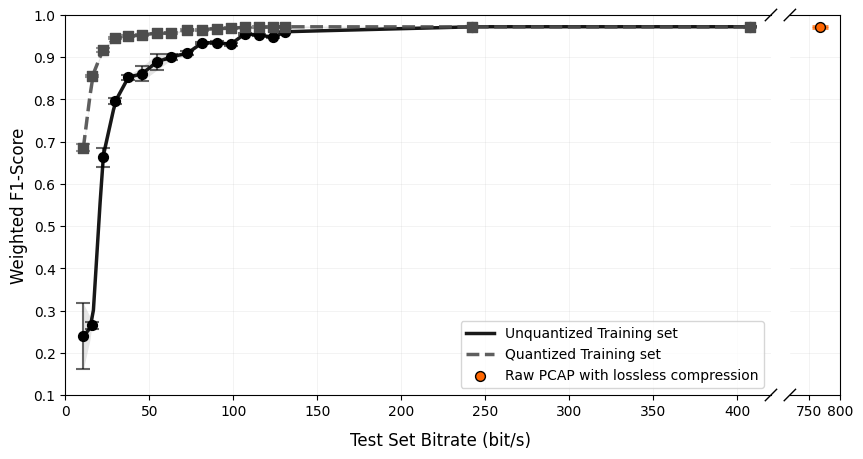


Figure with broken axis generated successfully!


In [34]:
# ============================================================
# TOPOLOGY SELECTION
# ============================================================
TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR = 8 * 1000 / 24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR = 8 * 1000 / 30716.04

# ============================================================
# REFERENCE POINT FOR UNQUANTIZED RAW PCAP DATA
# ============================================================
REFERENCE_X = 11058.76 * 0.2667 * MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.972  # F1-score obtained with unquantized data
REFERENCE_STD = 0.002  # Set to a float value (e.g., 0.01) or None if not available


F1_TYPE = 'weighted'
# ============================================================
# PASTE YOUR DATA HERE
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.2390 ± 0.0779
b=2: 0.2655 ± 0.0084
b=3: 0.6632 ± 0.0226
b=4: 0.7957 ± 0.0075
b=5: 0.8521 ± 0.0056
b=6: 0.8611 ± 0.0171
b=7: 0.8885 ± 0.0194
b=8: 0.9009 ± 0.0071
b=9: 0.9094 ± 0.0052
b=10: 0.9342 ± 0.0025
b=11: 0.9344 ± 0.0042
b=12: 0.9308 ± 0.0037
b=13: 0.9556 ± 0.0019
b=14: 0.9523 ± 0.0031
b=15: 0.9473 ± 0.0019
b=16: 0.9604 ± 0.0012
b=32: 0.9722 ± 0.0014
b=64: 0.9722 ± 0.0015

Quantitative training + Quantitative testing：
b=1: 0.6855 ± 0.0079
b=2: 0.8555 ± 0.0016
b=3: 0.9177 ± 0.0043
b=4: 0.9455 ± 0.0025
b=5: 0.9496 ± 0.0028
b=6: 0.9528 ± 0.0023
b=7: 0.9571 ± 0.0013
b=8: 0.9569 ± 0.0023
b=9: 0.9641 ± 0.0021
b=10: 0.9656 ± 0.0024
b=11: 0.9678 ± 0.0016
b=12: 0.9687 ± 0.0017
b=13: 0.9707 ± 0.0014
b=14: 0.9711 ± 0.0020
b=15: 0.9719 ± 0.0021
b=16: 0.9721 ± 0.0018
b=32: 0.9716 ± 0.0014
b=64: 0.9716 ± 0.0014
"""


fig, (ax1, ax2) = plot_f1(0.1)
plt.tight_layout()
plt.savefig('dev_type-f1-weight_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure with broken axis generated successfully!")

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_78541/1812495600.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


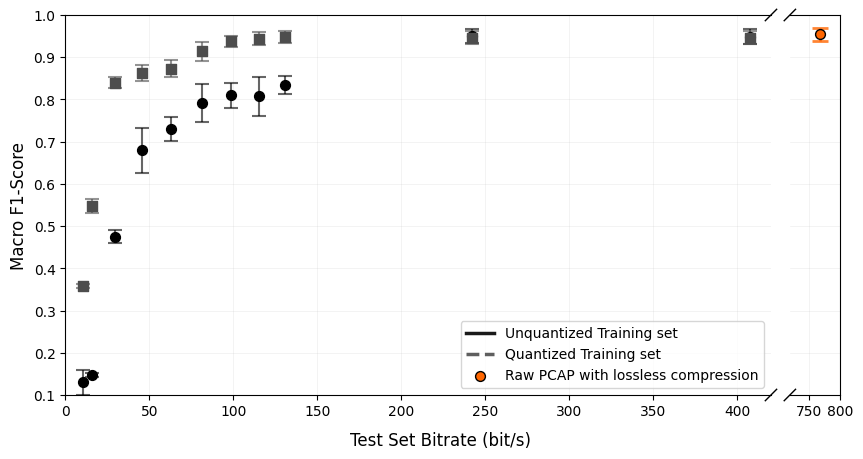


Figure generated successfully!


In [ ]:
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04

REFERENCE_X = 11058.76*0.2667*MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.954  # F1-score obtained with unquantized data
REFERENCE_STD = 0.016  # Set to a float value (e.g., 0.01) or None if not available



# data_text = """
# Raw training + quantitative testing:
# b=1: 0.1300 ± 0.0298
# b=2: 0.1470 ± 0.0042
# b=3: 0.4089 ± 0.0199
# b=4: 0.4748 ± 0.0156
# b=5: 0.5535 ± 0.0210
# b=6: 0.6792 ± 0.0526
# b=7: 0.7044 ± 0.0333
# b=8: 0.7300 ± 0.0294
# b=9: 0.7762 ± 0.0529
# b=10: 0.7916 ± 0.0460
# b=11: 0.6698 ± 0.0239
# b=12: 0.8098 ± 0.0300
# b=13: 0.8193 ± 0.0574
# b=14: 0.8075 ± 0.0462
# b=15: 0.9262 ± 0.0167
# b=16: 0.8342 ± 0.0208
# b=32: 0.9503 ± 0.0162
# b=64: 0.9488 ± 0.0178

# Quantitative training + Quantitative testing：
# b=1: 0.3579 ± 0.0040
# b=2: 0.5478 ± 0.0165
# b=3: 0.6856 ± 0.0143
# b=4: 0.8399 ± 0.0139
# b=5: 0.8575 ± 0.0191
# b=6: 0.8624 ± 0.0192
# b=7: 0.8693 ± 0.0173
# b=8: 0.8731 ± 0.0205
# b=9: 0.9082 ± 0.0230
# b=10: 0.9139 ± 0.0233
# b=11: 0.9262 ± 0.0201
# b=12: 0.9375 ± 0.0129
# b=13: 0.9401 ± 0.0118
# b=14: 0.9440 ± 0.0162
# b=15: 0.9472 ± 0.0143
# b=16: 0.9478 ± 0.0139
# b=32: 0.9458 ± 0.0155
# b=64: 0.9458 ± 0.0155
# """



data_text = """
Raw training + quantitative testing:
b=1: 0.1300 ± 0.0298
b=2: 0.1470 ± 0.0042
b=3: 0.4089 ± 0.0199
b=4: 0.4748 ± 0.0156
b=5: 0.5535 ± 0.0210
b=6: 0.6792 ± 0.0526
b=7: 0.7044 ± 0.0333
b=8: 0.7300 ± 0.0294
b=9: 0.7762 ± 0.0529
b=10: 0.7916 ± 0.0460
b=11: 0.6698 ± 0.0239
b=12: 0.8098 ± 0.0300
b=13: 0.8193 ± 0.0574
b=14: 0.8075 ± 0.0462
b=15: 0.9262 ± 0.0167
b=16: 0.8342 ± 0.0208
b=17: 0.8381 ± 0.0137
b=18: 0.9039 ± 0.0181
b=19: 0.7740 ± 0.0092
b=20: 0.8868 ± 0.0245
b=21: 0.7956 ± 0.0275
b=22: 0.7618 ± 0.0289
b=23: 0.9194 ± 0.0144
b=24: 0.9440 ± 0.0140
b=25: 0.9472 ± 0.0199
b=26: 0.9506 ± 0.0166
b=27: 0.9500 ± 0.0166
b=28: 0.9437 ± 0.0142
b=29: 0.9481 ± 0.0178
b=30: 0.9486 ± 0.0177
b=31: 0.9487 ± 0.0178
b=32: 0.9503 ± 0.0162
b=33: 0.9489 ± 0.0179
b=34: 0.9488 ± 0.0178
b=35: 0.9488 ± 0.0178
b=36: 0.9489 ± 0.0179
b=37: 0.9504 ± 0.0162
b=38: 0.9488 ± 0.0178
b=39: 0.9488 ± 0.0179
b=40: 0.9489 ± 0.0178
b=41: 0.9504 ± 0.0162
b=42: 0.9489 ± 0.0179
b=43: 0.9488 ± 0.0178
b=44: 0.9504 ± 0.0161
b=45: 0.9489 ± 0.0178
b=46: 0.9504 ± 0.0162
b=47: 0.9504 ± 0.0162
b=48: 0.9489 ± 0.0179
b=49: 0.9489 ± 0.0179
b=50: 0.9488 ± 0.0179
b=51: 0.9504 ± 0.0162
b=52: 0.9503 ± 0.0161
b=53: 0.9489 ± 0.0178
b=54: 0.9489 ± 0.0178
b=55: 0.9488 ± 0.0179
b=56: 0.9488 ± 0.0178
b=57: 0.9488 ± 0.0178
b=58: 0.9488 ± 0.0178
b=59: 0.9488 ± 0.0178
b=60: 0.9488 ± 0.0178
b=61: 0.9488 ± 0.0178
b=62: 0.9488 ± 0.0178
b=63: 0.9488 ± 0.0178
b=64: 0.9488 ± 0.0178

Quantitative training + Quantitative testing：
b=1: 0.3579 ± 0.0040
b=2: 0.5478 ± 0.0165
b=3: 0.6856 ± 0.0143
b=4: 0.8399 ± 0.0139
b=5: 0.8575 ± 0.0191
b=6: 0.8624 ± 0.0192
b=7: 0.8693 ± 0.0173
b=8: 0.8731 ± 0.0205
b=9: 0.9082 ± 0.0230
b=10: 0.9139 ± 0.0233
b=11: 0.9262 ± 0.0201
b=12: 0.9375 ± 0.0129
b=13: 0.9401 ± 0.0118
b=14: 0.9440 ± 0.0162
b=15: 0.9472 ± 0.0143
b=16: 0.9478 ± 0.0139
b=17: 0.9477 ± 0.0137
b=18: 0.9469 ± 0.0140
b=19: 0.9456 ± 0.0162
b=20: 0.9458 ± 0.0161
b=21: 0.9469 ± 0.0144
b=22: 0.9454 ± 0.0158
b=23: 0.9455 ± 0.0153
b=24: 0.9471 ± 0.0138
b=25: 0.9454 ± 0.0161
b=26: 0.9453 ± 0.0158
b=27: 0.9454 ± 0.0161
b=28: 0.9454 ± 0.0160
b=29: 0.9454 ± 0.0160
b=30: 0.9454 ± 0.0160
b=31: 0.9454 ± 0.0160
b=32: 0.9458 ± 0.0155
b=33: 0.9458 ± 0.0155
b=34: 0.9458 ± 0.0155
b=35: 0.9458 ± 0.0155
b=36: 0.9458 ± 0.0155
b=37: 0.9458 ± 0.0155
b=38: 0.9458 ± 0.0155
b=39: 0.9458 ± 0.0155
b=40: 0.9458 ± 0.0155
b=41: 0.9458 ± 0.0155
b=42: 0.9458 ± 0.0155
b=43: 0.9458 ± 0.0155
b=44: 0.9458 ± 0.0155
b=45: 0.9458 ± 0.0155
b=46: 0.9458 ± 0.0155
b=47: 0.9458 ± 0.0155
b=48: 0.9458 ± 0.0155
b=49: 0.9458 ± 0.0155
b=50: 0.9458 ± 0.0155
b=51: 0.9458 ± 0.0155
b=52: 0.9458 ± 0.0155
b=53: 0.9458 ± 0.0155
b=54: 0.9458 ± 0.0155
b=55: 0.9458 ± 0.0155
b=56: 0.9458 ± 0.0155
b=57: 0.9458 ± 0.0155
b=58: 0.9458 ± 0.0155
b=59: 0.9458 ± 0.0155
b=60: 0.9458 ± 0.0155
b=61: 0.9458 ± 0.0155
b=62: 0.9458 ± 0.0155
b=63: 0.9458 ± 0.0155
b=64: 0.9458 ± 0.0155
"""

F1_TYPE = 'macro'

fig, (ax1, ax2) = plot_f1(0.1, select='even')
plt.tight_layout()
plt.savefig('dev_type-f1-macro_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

## Device Name

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_14799/1171976963.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


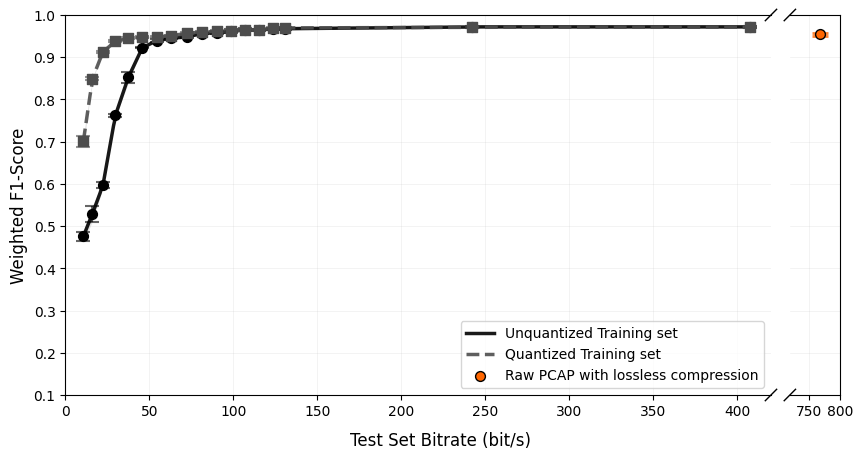


Figure generated successfully!


In [36]:
# ============================================================
# REFERENCE POINT FOR UNQUANTIZED RAW PCAP DATA
# Set these values manually for the orange reference point
# ============================================================
REFERENCE_X = 11058.76*0.2667*MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.954  # F1-score obtained with unquantized data
REFERENCE_STD = 0.003  # Set to a float value (e.g., 0.01) or None if not available
# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.4756 ± 0.0101
b=2: 0.5295 ± 0.0192
b=3: 0.5968 ± 0.0072
b=4: 0.7621 ± 0.0045
b=5: 0.8522 ± 0.0132
b=6: 0.9222 ± 0.0010
b=7: 0.9394 ± 0.0044
b=8: 0.9447 ± 0.0013
b=9: 0.9485 ± 0.0030
b=10: 0.9560 ± 0.0021
b=11: 0.9582 ± 0.0028
b=12: 0.9613 ± 0.0044
b=13: 0.9651 ± 0.0033
b=14: 0.9646 ± 0.0031
b=15: 0.9671 ± 0.0013
b=16: 0.9676 ± 0.0035
b=32: 0.9719 ± 0.0020
b=64: 0.9719 ± 0.0020

Quantitative training + Quantitative testing：
b=1: 0.7008 ± 0.0132
b=2: 0.8496 ± 0.0027
b=3: 0.9126 ± 0.0028
b=4: 0.9376 ± 0.0023
b=5: 0.9444 ± 0.0024
b=6: 0.9473 ± 0.0021
b=7: 0.9483 ± 0.0026
b=8: 0.9511 ± 0.0021
b=9: 0.9567 ± 0.0020
b=10: 0.9599 ± 0.0023
b=11: 0.9611 ± 0.0024
b=12: 0.9619 ± 0.0026
b=13: 0.9646 ± 0.0028
b=14: 0.9650 ± 0.0028
b=15: 0.9686 ± 0.0027
b=16: 0.9694 ± 0.0021
b=32: 0.9710 ± 0.0021
b=64: 0.9710 ± 0.0021
"""



# ============================================================
# LZMA RESULTS - You need to define this dictionary
# ============================================================
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04

F1_TYPE = 'weighted'

fig, (ax1, ax2) = plot_f1(0.1)
plt.tight_layout()
plt.savefig('dev_name-f1-weigh_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_14799/2685690722.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


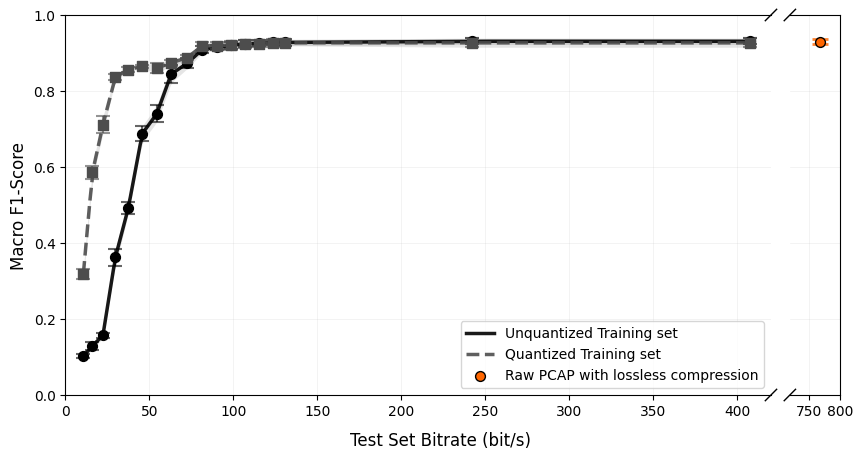


Figure generated successfully!


In [37]:
# ============================================================
# REFERENCE POINT FOR UNQUANTIZED RAW PCAP DATA
# Set these values manually for the orange reference point
# ============================================================
REFERENCE_X = 11058.76*0.2667*MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.93  # F1-score obtained with unquantized data
REFERENCE_STD = 0.007  # Set to a float value (e.g., 0.01) or None if not available
# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """

Raw training + quantitative testing:
b=1: 0.1021 ± 0.0045
b=2: 0.1292 ± 0.0098
b=3: 0.1572 ± 0.0068
b=4: 0.3623 ± 0.0223
b=5: 0.4923 ± 0.0161
b=6: 0.6879 ± 0.0200
b=7: 0.7397 ± 0.0222
b=8: 0.8445 ± 0.0229
b=9: 0.8733 ± 0.0139
b=10: 0.9088 ± 0.0085
b=11: 0.9145 ± 0.0074
b=12: 0.9201 ± 0.0098
b=13: 0.9243 ± 0.0090
b=14: 0.9256 ± 0.0084
b=15: 0.9277 ± 0.0075
b=16: 0.9278 ± 0.0083
b=32: 0.9308 ± 0.0083
b=64: 0.9308 ± 0.0083

Quantitative training + Quantitative testing：
b=1: 0.3188 ± 0.0138
b=2: 0.5861 ± 0.0176
b=3: 0.7116 ± 0.0215
b=4: 0.8364 ± 0.0071
b=5: 0.8564 ± 0.0059
b=6: 0.8648 ± 0.0035
b=7: 0.8602 ± 0.0137
b=8: 0.8740 ± 0.0076
b=9: 0.8880 ± 0.0060
b=10: 0.9185 ± 0.0097
b=11: 0.9195 ± 0.0089
b=12: 0.9207 ± 0.0116
b=13: 0.9233 ± 0.0103
b=14: 0.9246 ± 0.0094
b=15: 0.9269 ± 0.0099
b=16: 0.9268 ± 0.0078
b=32: 0.9267 ± 0.0115
b=64: 0.9267 ± 0.0115
"""



# ============================================================
# LZMA RESULTS - You need to define this dictionary
# ============================================================
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04

F1_TYPE = 'macro'

fig, (ax1, ax2) = plot_f1(0)
plt.tight_layout()
plt.savefig('dev_name-f1-weigh_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

# Old

/tmp/ipykernel_17856/2795063940.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


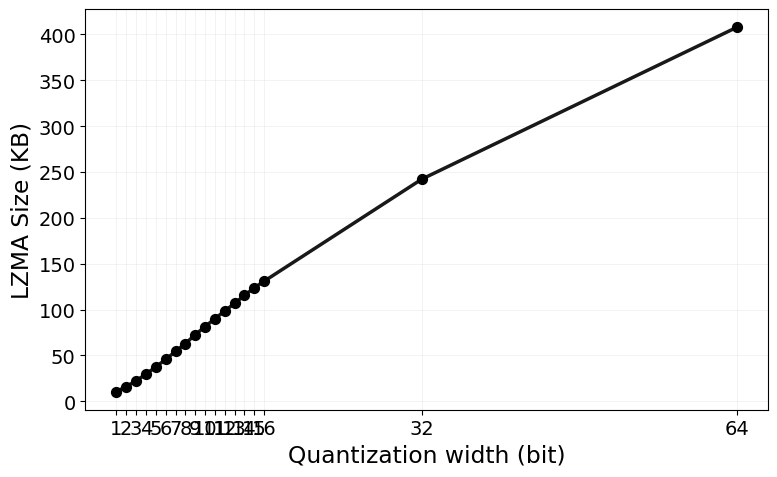


Figure generated successfully!


In [5]:
import matplotlib.pyplot as plt
import numpy as np
# Create a plot of LZMA Size vs Quantization bit width for Topology_B
b_values = []
lzma_values = []

for b_key in sorted(results.keys(), key=lambda x: int(x[1:])):
    b_values.append(int(b_key[1:]))  # Extract numeric value from 'bX'
    lzma_values.append(results[b_key][0])  # Get the LZMA size

# Convert to numpy arrays
b_values = np.array(b_values)
lzma_values = np.array(lzma_values)

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot the data
ax.plot(b_values, lzma_values, color='#000000', linestyle='-', linewidth=2.5, alpha=0.9)
ax.scatter(b_values, lzma_values, color='#000000', s=50, zorder=5, marker='o')

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('LZMA Size (KB)', fontsize='large')
ax.set_xticks(b_values)
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('lzma_size_vs_quantization.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 32 64]
  Range: 0.1300 - 0.9503

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 32 64]
  Range: 0.3579 - 0.9478


/tmp/ipykernel_17856/3432939442.py:188: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


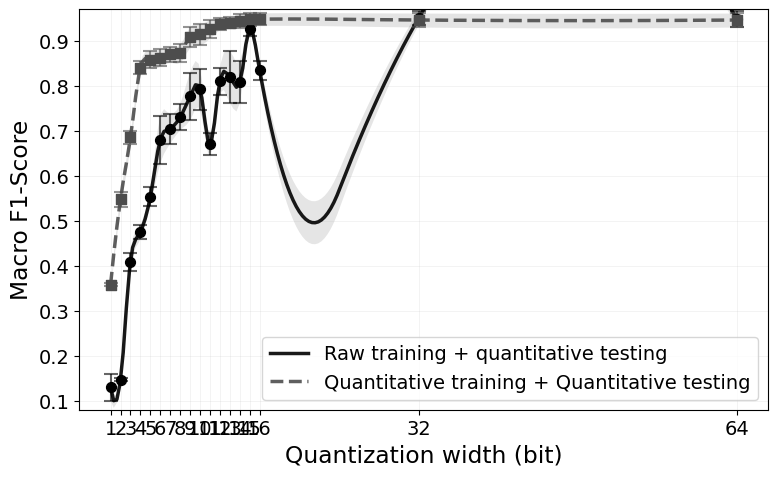


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.1300 ± 0.0298
b=2: 0.1470 ± 0.0042
b=3: 0.4089 ± 0.0199
b=4: 0.4748 ± 0.0156
b=5: 0.5535 ± 0.0210
b=6: 0.6792 ± 0.0526
b=7: 0.7044 ± 0.0333
b=8: 0.7300 ± 0.0294
b=9: 0.7762 ± 0.0529
b=10: 0.7916 ± 0.0460
b=11: 0.6698 ± 0.0239
b=12: 0.8098 ± 0.0300
b=13: 0.8193 ± 0.0574
b=14: 0.8075 ± 0.0462
b=15: 0.9262 ± 0.0167
b=16: 0.8342 ± 0.0208
b=32: 0.9503 ± 0.0162
b=64: 0.9488 ± 0.0178

Quantitative training + Quantitative testing：
b=1: 0.3579 ± 0.0040
b=2: 0.5478 ± 0.0165
b=3: 0.6856 ± 0.0143
b=4: 0.8399 ± 0.0139
b=5: 0.8575 ± 0.0191
b=6: 0.8624 ± 0.0192
b=7: 0.8693 ± 0.0173
b=8: 0.8731 ± 0.0205
b=9: 0.9082 ± 0.0230
b=10: 0.9139 ± 0.0233
b=11: 0.9262 ± 0.0201
b=12: 0.9375 ± 0.0129
b=13: 0.9401 ± 0.0118
b=14: 0.9440 ± 0.0162
b=15: 0.9472 ± 0.0143
b=16: 0.9478 ± 0.0139
b=32: 0.9458 ± 0.0155
b=64: 0.9458 ± 0.0155
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Macro F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_17856/3516715704.py:256: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


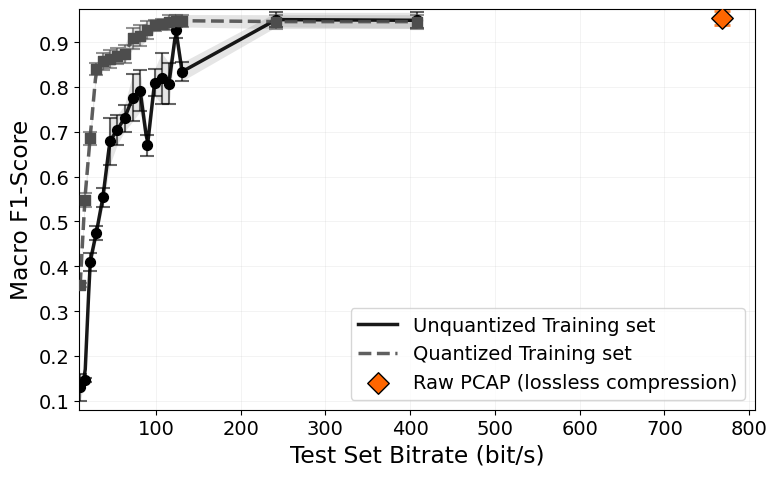


Figure generated successfully!


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re


# ============================================================
# REFERENCE POINT FOR UNQUANTIZED RAW PCAP DATA
# Set these values manually for the orange reference point
# ============================================================
REFERENCE_X = 11058.76*0.2667*MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.954  # F1-score obtained with unquantized data
REFERENCE_STD = 0.016  # Set to a float value (e.g., 0.01) or None if not available
# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.1300 ± 0.0298
b=2: 0.1470 ± 0.0042
b=3: 0.4089 ± 0.0199
b=4: 0.4748 ± 0.0156
b=5: 0.5535 ± 0.0210
b=6: 0.6792 ± 0.0526
b=7: 0.7044 ± 0.0333
b=8: 0.7300 ± 0.0294
b=9: 0.7762 ± 0.0529
b=10: 0.7916 ± 0.0460
b=11: 0.6698 ± 0.0239
b=12: 0.8098 ± 0.0300
b=13: 0.8193 ± 0.0574
b=14: 0.8075 ± 0.0462
b=15: 0.9262 ± 0.0167
b=16: 0.8342 ± 0.0208
b=32: 0.9503 ± 0.0162
b=64: 0.9488 ± 0.0178

Quantitative training + Quantitative testing：
b=1: 0.3579 ± 0.0040
b=2: 0.5478 ± 0.0165
b=3: 0.6856 ± 0.0143
b=4: 0.8399 ± 0.0139
b=5: 0.8575 ± 0.0191
b=6: 0.8624 ± 0.0192
b=7: 0.8693 ± 0.0173
b=8: 0.8731 ± 0.0205
b=9: 0.9082 ± 0.0230
b=10: 0.9139 ± 0.0233
b=11: 0.9262 ± 0.0201
b=12: 0.9375 ± 0.0129
b=13: 0.9401 ± 0.0118
b=14: 0.9440 ± 0.0162
b=15: 0.9472 ± 0.0143
b=16: 0.9478 ± 0.0139
b=32: 0.9458 ± 0.0155
b=64: 0.9458 ± 0.0155
"""

# ============================================================
# LZMA RESULTS - You need to define this dictionary
# ============================================================
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04



# Load the CSV file
df = pd.read_csv('10-Los-compression_size_results/all_results.csv')  # Replace with your actual file path

# Filter rows where 'File Name' contains 'Topology_B'
topology_b_df = df[df['File Name'].str.contains(TOPOLOGY, na=False)]

# Extract b values and corresponding LZMA Size (KB)
results = {}
for _, row in topology_b_df.iterrows():
    filename = row['File Name']
    lzma_size = row['LZMA Size (KB)']
    
    # Extract b value (e.g., b1, b2, b3, etc.)
    match = re.search(r'b(\d+)', filename)
    if match:
        b_key = f"b{match.group(1)}"
        if b_key not in results:
            results[b_key] = []
        results[b_key].append(lzma_size)

# Display results
for b_key in sorted(results.keys(), key=lambda x: int(x[1:])):
    results[b_key] = [results[b_key][0] * MUL_FACTOR]
    print(f"{b_key}: {results[b_key]}")
    
    

# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Get the two conditions
cond_names = list(conditions.keys())
cond1_name = cond_names[0]
cond2_name = cond_names[1]
cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Map b values to LZMA sizes
lzma_for_b = []
for b in cond1['b']:
    b_key = f"b{b}"
    if b_key in results:
        lzma_for_b.append(results[b_key][0])
    else:
        lzma_for_b.append(np.nan)

lzma_for_b = np.array(lzma_for_b)

# Sort by LZMA size for proper interpolation
sort_idx = np.argsort(lzma_for_b)
lzma_sorted = lzma_for_b[sort_idx]
cond1_mean_sorted = cond1['mean'][sort_idx]
cond1_std_sorted = cond1['std'][sort_idx]
cond2_mean_sorted = cond2['mean'][sort_idx]
cond2_std_sorted = cond2['std'][sort_idx]

# Create interpolation functions for means
interp_cond1 = interp1d(lzma_sorted, cond1_mean_sorted, kind='linear')
interp_cond2 = interp1d(lzma_sorted, cond2_mean_sorted, kind='linear')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(lzma_sorted, cond1_std_sorted, kind='linear')
interp_cond2_std = interp1d(lzma_sorted, cond2_std_sorted, kind='linear')

# Extended arrays for smooth visualization
lzma_smooth = np.linspace(lzma_sorted.min(), lzma_sorted.max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(lzma_smooth)
cond2_smooth = interp_cond2(lzma_smooth)
cond1_std_smooth = interp_cond1_std(lzma_smooth)
cond2_std_smooth = interp_cond2_std(lzma_smooth)

# Professional black and white styling
color_cond1 = '#000000'
color_cond2 = '#4D4D4D'
color_reference = '#FF6600'  # Orange color for reference point
linestyle_cond1 = '-'
linestyle_cond2 = '--'
marker_cond1 = 'o'
marker_cond2 = 's'
marker_reference = 'D'  # Diamond marker for reference

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

cond1_name_label = "Unquantized Training set"
cond2_name_label = "Quantized Training set"
reference_label = "Raw PCAP (lossless compression)"

# Plot Condition 1 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(lzma_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name_label, alpha=0.9)
ax.errorbar(lzma_sorted, cond1_mean_sorted, yerr=cond1_std_sorted,
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond1_mean_sorted, 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(lzma_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name_label, alpha=0.9)
ax.errorbar(lzma_sorted, cond2_mean_sorted, yerr=cond2_std_sorted,
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond2_mean_sorted, 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Plot reference point (orange) for raw PCAP with lossless compression
if REFERENCE_STD is not None:
    ax.errorbar(REFERENCE_X, REFERENCE_Y, yerr=REFERENCE_STD,
               fmt='none', ecolor=color_reference, capsize=6, capthick=2, 
               alpha=0.8, linewidth=2, zorder=6)
ax.scatter(REFERENCE_X, REFERENCE_Y, 
          color=color_reference, s=120, zorder=7, marker=marker_reference,
          edgecolors='black', linewidths=1.0, label=reference_label)

# Customize figure
ax.set_xlabel('Test Set Bitrate (bit/s)', fontsize='large')
ax.set_ylabel('Macro F1-Score', fontsize='large')
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium', frameon=True, fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min(), REFERENCE_Y) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max(), REFERENCE_Y) + 0.02)
ax.set_ylim(y_min, y_max)

# Adjust x-axis to include reference point if it's outside current range
x_min = min(lzma_sorted.min(), REFERENCE_X) * 0.9
x_max = max(lzma_sorted.max(), REFERENCE_X) * 1.05
ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.savefig('dev_type-f1-macro_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

# Device Name

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.4407 - 0.9603

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.6273 - 0.9610


/tmp/ipykernel_179739/3341788551.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


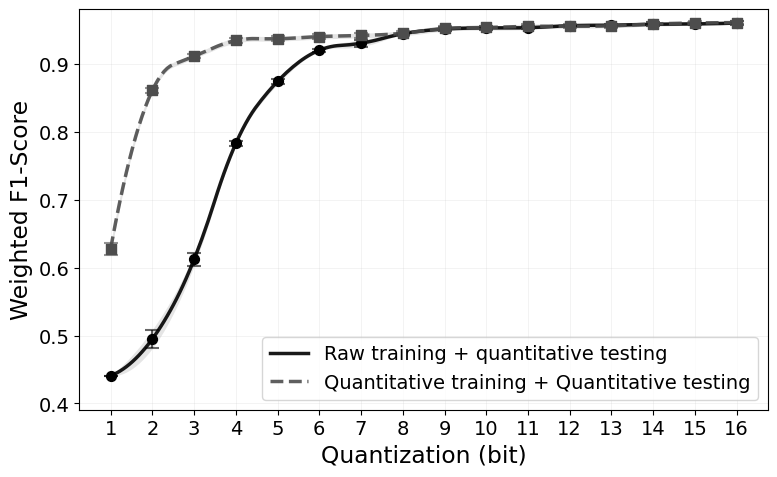


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.4407 ± 0.0004
b=2: 0.4949 ± 0.0138
b=3: 0.6120 ± 0.0091
b=4: 0.7829 ± 0.0037
b=5: 0.8744 ± 0.0041
b=6: 0.9203 ± 0.0022
b=7: 0.9306 ± 0.0050
b=8: 0.9445 ± 0.0014
b=9: 0.9515 ± 0.0024
b=10: 0.9532 ± 0.0033
b=11: 0.9535 ± 0.0026
b=12: 0.9564 ± 0.0016
b=13: 0.9572 ± 0.0024
b=14: 0.9585 ± 0.0028
b=15: 0.9590 ± 0.0019
b=16: 0.9603 ± 0.0024

Quantitative training + Quantitative testing：
b=1: 0.6273 ± 0.0085
b=2: 0.8611 ± 0.0042
b=3: 0.9115 ± 0.0034
b=4: 0.9346 ± 0.0038
b=5: 0.9372 ± 0.0033
b=6: 0.9403 ± 0.0037
b=7: 0.9420 ± 0.0034
b=8: 0.9452 ± 0.0037
b=9: 0.9523 ± 0.0038
b=10: 0.9538 ± 0.0021
b=11: 0.9554 ± 0.0035
b=12: 0.9555 ± 0.0029
b=13: 0.9562 ± 0.0028
b=14: 0.9589 ± 0.0027
b=15: 0.9604 ± 0.0024
b=16: 0.9610 ± 0.0025
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

b1: [10.763920088657262]
b2: [16.19166240179398]
b3: [22.41296404093757]
b4: [29.81341344782726]
b5: [37.51500844509904]
b6: [45.820929390637595]
b7: [54.42494377530437]
b8: [63.050323218748254]
b9: [72.6473041446749]
b10: [81.51482092092601]
b11: [90.17682617941635]
b12: [98.49902526497557]
b13: [106.88124999186093]
b14: [115.5076468190561]
b15: [123.78304625205593]
b16: [130.96781030367197]
b32: [242.11393298094416]
b64: [407.6768603635104]


/tmp/ipykernel_17856/370740901.py:256: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


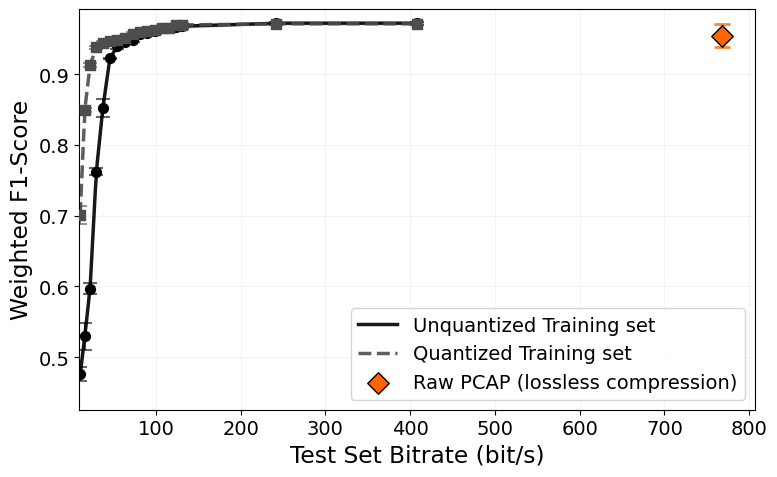


Figure generated successfully!


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re


# ============================================================
# REFERENCE POINT FOR UNQUANTIZED RAW PCAP DATA
# Set these values manually for the orange reference point
# ============================================================
REFERENCE_X = 11058.76*0.2667*MUL_FACTOR  # Bitrate of raw PCAP with lossless compression (bit/s)
REFERENCE_Y = 0.954  # F1-score obtained with unquantized data
REFERENCE_STD = 0.016  # Set to a float value (e.g., 0.01) or None if not available
# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.4756 ± 0.0101
b=2: 0.5295 ± 0.0192
b=3: 0.5968 ± 0.0072
b=4: 0.7621 ± 0.0045
b=5: 0.8522 ± 0.0132
b=6: 0.9222 ± 0.0010
b=7: 0.9394 ± 0.0044
b=8: 0.9447 ± 0.0013
b=9: 0.9485 ± 0.0030
b=10: 0.9560 ± 0.0021
b=11: 0.9582 ± 0.0028
b=12: 0.9613 ± 0.0044
b=13: 0.9651 ± 0.0033
b=14: 0.9646 ± 0.0031
b=15: 0.9671 ± 0.0013
b=16: 0.9676 ± 0.0035
b=32: 0.9719 ± 0.0020
b=64: 0.9719 ± 0.0020

Quantitative training + Quantitative testing：
b=1: 0.7008 ± 0.0132
b=2: 0.8496 ± 0.0027
b=3: 0.9126 ± 0.0028
b=4: 0.9376 ± 0.0023
b=5: 0.9444 ± 0.0024
b=6: 0.9473 ± 0.0021
b=7: 0.9483 ± 0.0026
b=8: 0.9511 ± 0.0021
b=9: 0.9567 ± 0.0020
b=10: 0.9599 ± 0.0023
b=11: 0.9611 ± 0.0024
b=12: 0.9619 ± 0.0026
b=13: 0.9646 ± 0.0028
b=14: 0.9650 ± 0.0028
b=15: 0.9686 ± 0.0027
b=16: 0.9694 ± 0.0021
b=32: 0.9710 ± 0.0021
b=64: 0.9710 ± 0.0021
"""

# ============================================================
# LZMA RESULTS - You need to define this dictionary
# ============================================================
import pandas as pd
import re

TOPOLOGY = 'Topology_B'
if 'A' in TOPOLOGY:
    MUL_FACTOR=8*1000/24557.42
elif 'B' in TOPOLOGY:
    MUL_FACTOR=8*1000/30716.04



# Load the CSV file
df = pd.read_csv('10-Los-compression_size_results/all_results.csv')  # Replace with your actual file path

# Filter rows where 'File Name' contains 'Topology_B'
topology_b_df = df[df['File Name'].str.contains(TOPOLOGY, na=False)]

# Extract b values and corresponding LZMA Size (KB)
results = {}
for _, row in topology_b_df.iterrows():
    filename = row['File Name']
    lzma_size = row['LZMA Size (KB)']
    
    # Extract b value (e.g., b1, b2, b3, etc.)
    match = re.search(r'b(\d+)', filename)
    if match:
        b_key = f"b{match.group(1)}"
        if b_key not in results:
            results[b_key] = []
        results[b_key].append(lzma_size)

# Display results
for b_key in sorted(results.keys(), key=lambda x: int(x[1:])):
    results[b_key] = [results[b_key][0] * MUL_FACTOR]
    print(f"{b_key}: {results[b_key]}")
    
    

# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Get the two conditions
cond_names = list(conditions.keys())
cond1_name = cond_names[0]
cond2_name = cond_names[1]
cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Map b values to LZMA sizes
lzma_for_b = []
for b in cond1['b']:
    b_key = f"b{b}"
    if b_key in results:
        lzma_for_b.append(results[b_key][0])
    else:
        lzma_for_b.append(np.nan)

lzma_for_b = np.array(lzma_for_b)

# Sort by LZMA size for proper interpolation
sort_idx = np.argsort(lzma_for_b)
lzma_sorted = lzma_for_b[sort_idx]
cond1_mean_sorted = cond1['mean'][sort_idx]
cond1_std_sorted = cond1['std'][sort_idx]
cond2_mean_sorted = cond2['mean'][sort_idx]
cond2_std_sorted = cond2['std'][sort_idx]

# Create interpolation functions for means
interp_cond1 = interp1d(lzma_sorted, cond1_mean_sorted, kind='linear')
interp_cond2 = interp1d(lzma_sorted, cond2_mean_sorted, kind='linear')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(lzma_sorted, cond1_std_sorted, kind='linear')
interp_cond2_std = interp1d(lzma_sorted, cond2_std_sorted, kind='linear')

# Extended arrays for smooth visualization
lzma_smooth = np.linspace(lzma_sorted.min(), lzma_sorted.max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(lzma_smooth)
cond2_smooth = interp_cond2(lzma_smooth)
cond1_std_smooth = interp_cond1_std(lzma_smooth)
cond2_std_smooth = interp_cond2_std(lzma_smooth)

# Professional black and white styling
color_cond1 = '#000000'
color_cond2 = '#4D4D4D'
color_reference = '#FF6600'  # Orange color for reference point
linestyle_cond1 = '-'
linestyle_cond2 = '--'
marker_cond1 = 'o'
marker_cond2 = 's'
marker_reference = 'D'  # Diamond marker for reference

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

cond1_name_label = "Unquantized Training set"
cond2_name_label = "Quantized Training set"
reference_label = "Raw PCAP (lossless compression)"

# Plot Condition 1 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(lzma_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name_label, alpha=0.9)
ax.errorbar(lzma_sorted, cond1_mean_sorted, yerr=cond1_std_sorted,
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond1_mean_sorted, 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(lzma_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(lzma_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name_label, alpha=0.9)
ax.errorbar(lzma_sorted, cond2_mean_sorted, yerr=cond2_std_sorted,
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(lzma_sorted, cond2_mean_sorted, 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Plot reference point (orange) for raw PCAP with lossless compression
if REFERENCE_STD is not None:
    ax.errorbar(REFERENCE_X, REFERENCE_Y, yerr=REFERENCE_STD,
               fmt='none', ecolor=color_reference, capsize=6, capthick=2, 
               alpha=0.8, linewidth=2, zorder=6)
ax.scatter(REFERENCE_X, REFERENCE_Y, 
          color=color_reference, s=120, zorder=7, marker=marker_reference,
          edgecolors='black', linewidths=1.0, label=reference_label)

# Customize figure
ax.set_xlabel('Test Set Bitrate (bit/s)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium', frameon=True, fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min(), REFERENCE_Y) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max(), REFERENCE_Y) + 0.02)
ax.set_ylim(y_min, y_max)

# Adjust x-axis to include reference point if it's outside current range
x_min = min(lzma_sorted.min(), REFERENCE_X) * 0.9
x_max = max(lzma_sorted.max(), REFERENCE_X) * 1.05
ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.savefig('dev_name-f1-weigh_vs_lzma_bitrate-topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.1021 - 0.9278

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.3188 - 0.9269


/tmp/ipykernel_179739/173647803.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


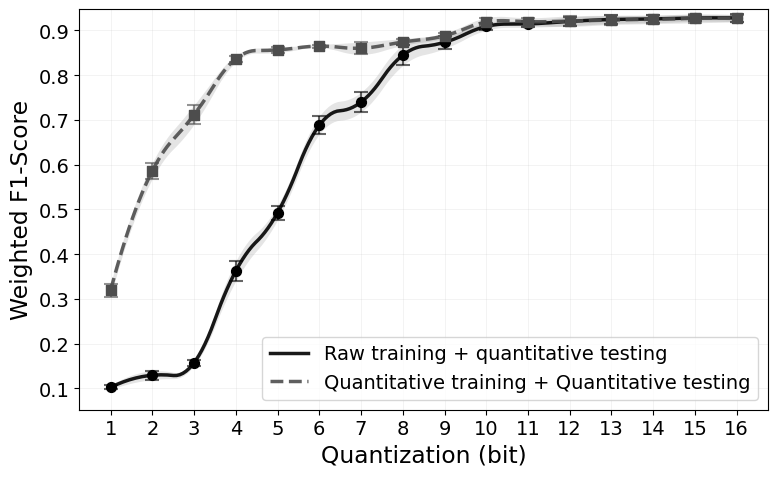


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.1021 ± 0.0045
b=2: 0.1292 ± 0.0098
b=3: 0.1572 ± 0.0068
b=4: 0.3623 ± 0.0223
b=5: 0.4923 ± 0.0161
b=6: 0.6879 ± 0.0200
b=7: 0.7397 ± 0.0222
b=8: 0.8445 ± 0.0229
b=9: 0.8733 ± 0.0139
b=10: 0.9088 ± 0.0085
b=11: 0.9145 ± 0.0074
b=12: 0.9201 ± 0.0098
b=13: 0.9243 ± 0.0090
b=14: 0.9256 ± 0.0084
b=15: 0.9277 ± 0.0075
b=16: 0.9278 ± 0.0083

Quantitative training + Quantitative testing：
b=1: 0.3188 ± 0.0138
b=2: 0.5861 ± 0.0176
b=3: 0.7116 ± 0.0215
b=4: 0.8364 ± 0.0071
b=5: 0.8564 ± 0.0059
b=6: 0.8648 ± 0.0035
b=7: 0.8602 ± 0.0137
b=8: 0.8740 ± 0.0076
b=9: 0.8880 ± 0.0060
b=10: 0.9185 ± 0.0097
b=11: 0.9195 ± 0.0089
b=12: 0.9207 ± 0.0116
b=13: 0.9233 ± 0.0103
b=14: 0.9246 ± 0.0094
b=15: 0.9269 ± 0.0099
b=16: 0.9268 ± 0.0078
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Macro F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")